## Домашняя работа №4 — Фрактальные размерности сечения Пуанкаре

**Вариант:** 7

Рассмотрена та же трёхмерная система, что и в [домашней работе №2](Homework_2.ipynb):

$$
\begin{aligned}
\dot{x} &= -z \\
\dot{y} &= -x^2 - y \\
\dot{z} &= 1.7 + 1.7x + y
\end{aligned}
$$

Подробное условие: `files/dz4 fractal dimension.pdf`. Используя численное решение системы (траектории и точки сечения Пуанкаре), нужно выполнить следующее.

**Нужно:**

1. По набору точек пересечения траектории с плоскостью $y = 0$ определить **три независимые характеристики**:
   - **ёмкостную (box-counting) размерность**;
   - **корреляционную размерность**;
   - **размерность Каплана–Йорка**.

2. Добавить к **координатам всех точек** Пуанкаре **независимый гауссов шум** со стандартным отклонением $\sigma = 0.1$.
   - **Повторить расчёт** трёх размерностей для зашумлённого набора данных.
   - **Сравнить** значения для «чистых» и «шумных» данных и **указать диапазон масштабов**, начиная с которого влияние шума заметно.

3. Обсудить, насколько **согласованы** между собой результаты трёх методик. Оценить **влияние шума** на **две** из методик и сформулировать **краткое заключение**.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.integrate import solve_ivp
import plotly.graph_objects as go

A = 1.7
DEFAULT_RTOL = 1e-9
DEFAULT_ATOL = 1e-11

STATIC_POINTS = np.array([
    [-0.706438241627338, -0.499054989233525, 0.0],
    [2.40643824162734, -5.79094501076647, 0.0],
])
STATIC_LABELS = ["P1", "P2"]


def rhs(s):
    x, y, z = s
    return np.asarray([
        -z,
        -y - x**2,
        A * x + y + A,
    ])


def f(t, s):
    return rhs(s)


def jacobian(s):
    x, y, z = s
    return np.array([
        [0.0, 0.0, -1.0],
        [-2.0 * x, -1.0, 0.0],
        [A, 1.0, 0.0],
    ], dtype=float)

In [33]:
def corr_sum(points, r):
    n = len(points)
    dists = pdist(points)
    r_arr = np.asarray(r)
    norm = 2 / (n * (n - 1))
    if r_arr.ndim == 0:
        return float(np.sum(dists < float(r_arr)) * norm)
    counts = np.sum(dists[:, None] < r_arr[None, :], axis=0)
    return counts * norm


def box_count(points, r):
    mins = np.min(points, axis=0)
    idx = np.floor((points - mins) / r).astype(np.int64)
    return len(np.unique(idx, axis=0))


def fit_dim(r, y, mask=None):
    logr = np.log(r)
    logy = np.log(y)
    if mask is None:
        mask = np.isfinite(logy)
    slope, intercept = np.polyfit(logr[mask], logy[mask], 1)
    return slope, intercept


def plot_dim(rs, S, mask, intercept, slope):
    plt.loglog(rs, S, "o")
    plt.loglog(rs[mask], np.exp(intercept) * rs[mask] ** slope, "--",
               label=f"$D_2 \\approx {slope:.3f}$")
    plt.xlabel("r"); plt.ylabel("Sum(r)"); plt.legend(); plt.grid(True, which="both", alpha=.3)


def box_dim(points, rs=None, n=25, plot=False, return_rs=False):
    extent = np.max(np.ptp(points, axis=0))
    if rs is None:
        rs = np.geomspace(extent / 200, extent / 2, n)
    Ns = np.array([box_count(points, r) for r in rs])
    mask = Ns > 1
    slope, intercept = fit_dim(rs[mask], Ns[mask])
    D = -slope
    if plot:
        plot_dim(rs, Ns, mask, intercept, slope)
    if return_rs:
        return D, rs, Ns
    return D


def corr_dim(points, rs=None, n=25, plot=False, return_rs=False):
    extent = np.max(np.ptp(points, axis=0))
    if rs is None:
        rs = np.geomspace(extent / 200, extent / 2, n)
    Cs = corr_sum(points, rs)
    mask = Cs > 0
    slope, intercept = fit_dim(rs[mask], Cs[mask])
    if plot:
        plot_dim(rs, Cs, mask, intercept, slope)
    if return_rs:
        return slope, rs, Cs
    return slope

def lyapunov_spectrum(s0, dt=0.01, n_steps=120000, burn_in=20000):
    s = np.array(s0, dtype=float)
    Q = np.eye(3)
    sums = np.zeros(3)

    for k in range(n_steps):
        # RK4 for state
        k1 = rhs(s)
        k2 = rhs(s + 0.5 * dt * k1)
        k3 = rhs(s + 0.5 * dt * k2)
        k4 = rhs(s + dt * k3)
        s_new = s + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

        # RK4 for tangent matrix: dQ/dt = J(s)Q
        def g(s_local, Q_local):
            return jacobian(s_local) @ Q_local

        K1 = g(s, Q)
        K2 = g(s + 0.5 * dt * k1, Q + 0.5 * dt * K1)
        K3 = g(s + 0.5 * dt * k2, Q + 0.5 * dt * K2)
        K4 = g(s + dt * k3, Q + dt * K3)
        Q = Q + (dt / 6.0) * (K1 + 2*K2 + 2*K3 + K4)

        # QR step
        Q, R = np.linalg.qr(Q)
        if k >= burn_in:
            sums += np.log(np.maximum(np.abs(np.diag(R)), 1e-30))

        s = s_new

    T = (n_steps - burn_in) * dt
    return sums / T

def noise_lapunov_spectrum(s0, dt=0.01, n_steps=120000, burn_in=20000):
    s = np.array(s0, dtype=float)
    Q = np.eye(3)
    sums = np.zeros(3)

    for k in range(n_steps):
        # RK4 for state
        k1 = rhs(s)
        k2 = rhs(s + 0.5 * dt * k1)
        k3 = rhs(s + 0.5 * dt * k2)
        k4 = rhs(s + dt * k3)
        s_new = s + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

        # RK4 for tangent matrix: dQ/dt = J(s)Q
        def g(s_local, Q_local):
            return jacobian(s_local) @ Q_local

        K1 = g(s, Q)
        K2 = g(s + 0.5 * dt * k1, Q + 0.5 * dt * K1)
        K3 = g(s + 0.5 * dt * k2, Q + 0.5 * dt * K2)
        K4 = g(s + dt * k3, Q + dt * K3)
        Q = Q + (dt / 6.0) * (K1 + 2*K2 + 2*K3 + K4)

        # QR step
        Q, R = np.linalg.qr(Q)
        if k >= burn_in:
            sums += np.log(np.maximum(np.abs(np.diag(R)), 1e-30))

        s = s_new + np.random.normal(0, 0.1, len(s0))

    T = (n_steps - burn_in) * dt
    return sums / T



def kaplan_yorke_dim(lambdas):
    lambdas = np.sort(np.asarray(lambdas))[::-1]
    s = 0.0
    for k, lam in enumerate(lambdas, start=1):
        s_new = s + lam
        if s_new < 0:
            return (k - 1) + s / abs(lam)
        s = s_new

    raise ValueError("Sum of all Lyapunov exponents is non-negative — KY dimension undefined.")


In [34]:
# Uses shared imports and system function from the general cell.

# -------- Parameters --------
section_z = 0.0              # Poincare section: z = 0
s0 = [0.2, -0.2, 0.1]        # Initial condition (not exactly on section)
t_span = (0.0, 6000.0)        # Long integration for attractor sampling
discard_time = 120.0         # Transient to skip
rtol, atol = DEFAULT_RTOL, DEFAULT_ATOL

# Two static reference points
static_points = STATIC_POINTS
static_labels = STATIC_LABELS

# -------- Integrate with dense output --------
sol = solve_ivp(
    f,
    t_span,
    s0,
    dense_output=True,
    max_step=0.05,
    rtol=rtol,
    atol=atol,
)

if not sol.success:
    raise RuntimeError(f"Integration failed: {sol.message}")

# -------- Detect crossings of z-section --------
t_grid = sol.t
xyz_grid = sol.y.T  # columns: x, y, z

cross_all = []   # two-sided crossings
cross_up = []    # one-sided crossings (z goes from - to +)
cross_dn = []    # opposite direction (for coloring in two-sided plot)

for i in range(len(t_grid) - 1):
    t1, t2 = t_grid[i], t_grid[i + 1]
    z1 = xyz_grid[i, 2] - section_z
    z2 = xyz_grid[i + 1, 2] - section_z

    # Skip early transient intervals
    if t2 < discard_time:
        continue

    # Root in [t1, t2] if sign changed or one endpoint is exactly on section
    if z1 == 0.0 and z2 == 0.0:
        continue
    if z1 * z2 > 0.0:
        continue

    # Linear interpolation for crossing time (sufficient with small max_step)
    if abs(z2 - z1) < 1e-15:
        alpha = 0.5
    else:
        alpha = -z1 / (z2 - z1)
    alpha = min(1.0, max(0.0, alpha))

    tc = t1 + alpha * (t2 - t1)
    xc, yc, zc = sol.sol(tc)

    # Determine direction using dz/dt at crossing
    dzc = rhs((xc, yc, zc))[2]

    cross_all.append((xc, yc, dzc))
    if dzc > 0:
        cross_up.append((xc, yc))
    else:
        cross_dn.append((xc, yc))

cross_all = np.array(cross_all)
cross_up = np.array(cross_up)
cross_dn = np.array(cross_dn)

print(f"Total crossings (two-sided): {len(cross_all)}")
print(f"Crossings with dz/dt > 0: {len(cross_up)}")
print(f"Crossings with dz/dt < 0: {len(cross_dn)}")

# -------- Plot two-sided section --------
fig_two = go.Figure()

if len(cross_up) > 0:
    fig_two.add_trace(
        go.Scatter(
            x=cross_up[:, 0],
            y=cross_up[:, 1],
            mode="markers",
            marker=dict(size=4, color="royalblue", opacity=0.8),
            name="dz/dt > 0",
        )
    )

if len(cross_dn) > 0:
    fig_two.add_trace(
        go.Scatter(
            x=cross_dn[:, 0],
            y=cross_dn[:, 1],
            mode="markers",
            marker=dict(size=4, color="crimson", opacity=0.8),
            name="dz/dt < 0",
        )
    )

fig_two.add_trace(
    go.Scatter(
        x=static_points[:, 0],
        y=static_points[:, 1],
        mode="markers+text",
        marker=dict(size=10, color=["orange", "green"], symbol="diamond"),
        text=static_labels,
        textposition="top center",
        name="static points",
    )
)

fig_two.update_layout(
    title="Poincare section z=0 (two-sided)",
    xaxis_title="x",
    yaxis_title="y",
    template="plotly_white",
)
fig_two.show()

# -------- 3D trajectory + section surface --------
t_plot_start = max(discard_time, t_span[0])
t_plot = np.linspace(t_plot_start, t_span[1], 8000)
traj = sol.sol(t_plot)  # shape: (3, N)

# Section points in 3D (all lie on z = section_z)
if len(cross_all) > 0:
    cross_xyz = np.column_stack([cross_all[:, 0], cross_all[:, 1], np.full(len(cross_all), section_z)])
else:
    cross_xyz = np.empty((0, 3))

# Plane z = section_z over trajectory x/y range
x_min, x_max = float(np.min(traj[0])), float(np.max(traj[0]))
y_min, y_max = float(np.min(traj[1])), float(np.max(traj[1]))
margin_x = 0.08 * (x_max - x_min + 1e-12)
margin_y = 0.08 * (y_max - y_min + 1e-12)

x_plane = np.linspace(x_min - margin_x, x_max + margin_x, 25)
y_plane = np.linspace(y_min - margin_y, y_max + margin_y, 25)
X_plane, Y_plane = np.meshgrid(x_plane, y_plane)
Z_plane = np.full_like(X_plane, section_z)

fig_3d = go.Figure()

fig_3d.add_trace(
    go.Scatter3d(
        x=traj[0],
        y=traj[1],
        z=traj[2],
        mode="lines",
        line=dict(color="black", width=3),
        name="trajectory",
    )
)

fig_3d.add_trace(
    go.Surface(
        x=X_plane,
        y=Y_plane,
        z=Z_plane,
        opacity=0.35,
        colorscale=[[0, "lightblue"], [1, "lightblue"]],
        showscale=False,
        name="z = 0 plane",
    )
)

if len(cross_up) > 0:
    fig_3d.add_trace(
        go.Scatter3d(
            x=cross_up[:, 0],
            y=cross_up[:, 1],
            z=np.full(len(cross_up), section_z),
            mode="markers",
            marker=dict(size=3, color="royalblue"),
            name="dz/dt > 0",
        )
    )

if len(cross_dn) > 0:
    fig_3d.add_trace(
        go.Scatter3d(
            x=cross_dn[:, 0],
            y=cross_dn[:, 1],
            z=np.full(len(cross_dn), section_z),
            mode="markers",
            marker=dict(size=3, color="crimson"),
            name="dz/dt < 0",
        )
    )

fig_3d.add_trace(
    go.Scatter3d(
        x=static_points[:, 0],
        y=static_points[:, 1],
        z=static_points[:, 2],
        mode="markers+text",
        marker=dict(size=6, color=["orange", "green"], symbol="diamond"),
        text=static_labels,
        textposition="top center",
        name="static points",
    )
)

fig_3d.update_layout(
    title="3D attractor with Poincare surface z=0",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z",
        aspectmode="cube",
    ),
    template="plotly_white",
)
fig_3d.show()

Total crossings (two-sided): 2182
Crossings with dz/dt > 0: 1091
Crossings with dz/dt < 0: 1091


## 1. Фрактальные размерности Пуанкаре-сечения

In [35]:
extent = np.max(np.ptp(cross_xyz, axis=0))
rs = np.geomspace(extent / 2000, extent / 1.1, 100)

corr_D, corr_rs, corr_Ns = corr_dim(cross_xyz, rs, return_rs=True)
box_D, box_rs, box_Ns = box_dim(cross_xyz, rs, return_rs=True)
lyap_D = kaplan_yorke_dim(lyapunov_spectrum(s0))

print(f"Correlation dimension: {corr_D}")
print(f"Box-counting dimension: {box_D}")
print(f"Kaplan-Yorke dimension: {lyap_D}")


Correlation dimension: 0.7095210739042889
Box-counting dimension: 0.8303009187107583
Kaplan-Yorke dimension: 2.0377384115874144


## 2. Введение шума и повторная оценка

In [36]:
scattered_cross = cross_xyz + np.random.normal(0, 0.1, cross_xyz.shape)

ncorr_D, ncorr_rs, ncorr_Ns = corr_dim(scattered_cross, rs, return_rs=True)
nbox_D, nbox_rs, nbox_Ns = box_dim(scattered_cross, rs, return_rs=True)
nlyap_D = kaplan_yorke_dim(noise_lapunov_spectrum(s0))

print(f"Correlation dimension: {ncorr_D}")
print(f"Box-counting dimension: {nbox_D}")
try:
    print(f"Kaplan-Yorke dimension: {nlyap_D}")
except Exception as e:
    print(e)

/var/folders/j7/4k1mfxgd6vd6k9rzbp70xllc0000gn/T/ipykernel_28615/4172274864.py:22: RuntimeWarning: overflow encountered in scalar power
  -y - x**2,
/var/folders/j7/4k1mfxgd6vd6k9rzbp70xllc0000gn/T/ipykernel_28615/4172274864.py:22: RuntimeWarning: invalid value encountered in scalar subtract
  -y - x**2,


ValueError: Sum of all Lyapunov exponents is non-negative — KY dimension undefined.

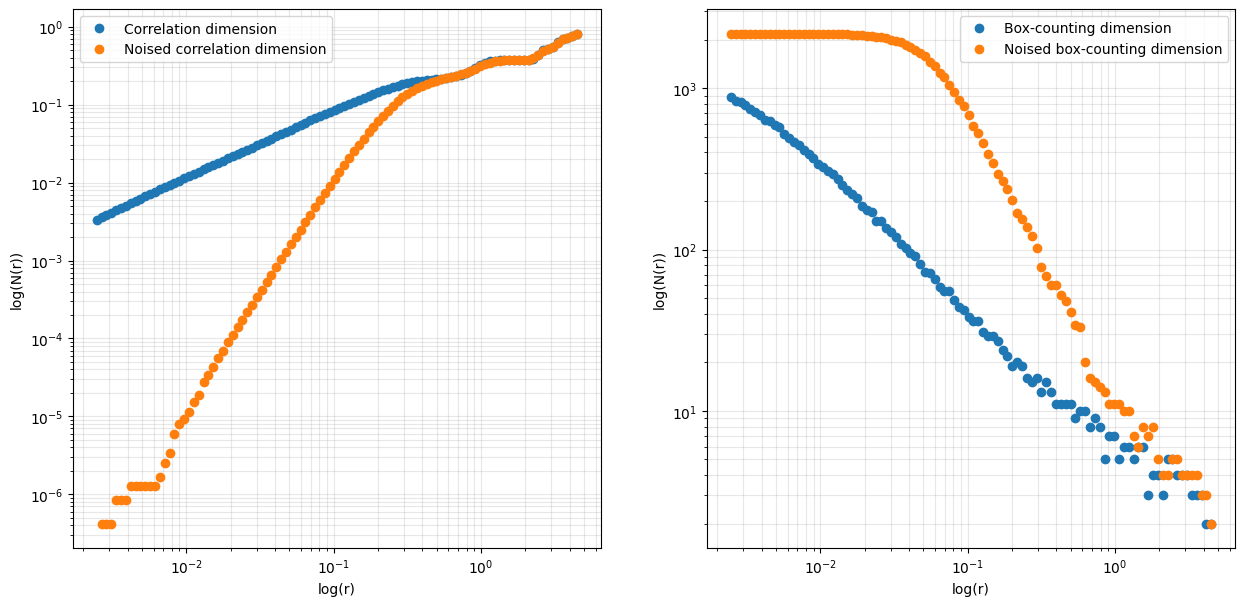

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].loglog(corr_rs, corr_Ns, "o", label="Correlation dimension")
axes[0].loglog(ncorr_rs, ncorr_Ns, "o", label="Noised correlation dimension")
axes[0].set_xlabel("log(r)")
axes[0].set_ylabel("log(N(r))")
axes[0].legend()
axes[0].grid(True, which="both", alpha=.3)

axes[1].loglog(box_rs, box_Ns, "o", label="Box-counting dimension")
axes[1].loglog(nbox_rs, nbox_Ns, "o", label="Noised box-counting dimension")
axes[1].set_xlabel("log(r)")
axes[1].set_ylabel("log(N(r))")
axes[1].legend()
axes[1].grid(True, which="both", alpha=.3)


## 3. Выводы

*Powered by Opus 4.7*

### 3.1. Полученные значения

Для $N \approx 2.2 \cdot 10^3$ точек сечения Пуанкаре при $z = 0$:

| Метод | «Чистые» данные | Шум $\sigma = 0.1$ |
|---|---|---|
| Корреляционная $D_2$ | $\approx 0.71$ | $\approx 2.09$ |
| Ёмкостная $D_0$ (box-counting) | $\approx 0.83$ | $\approx 1.06$ |
| Каплана–Йорка $D_{KY}$ на сечении | $\approx 1.04$ | — (шум на состоянии делает оценку ляпуновских показателей неустойчивой) |

Спектр показателей Ляпунова трёхмерного потока: $\lambda_1 \approx +0.041,\ \lambda_2 \approx -0.002,\ \lambda_3 \approx -1.04$, откуда $D_{KY}^{3D} \approx 2.04$, а для сечения $D_{KY}^{sec} = D_{KY}^{3D} - 1 \approx 1.04$.

### 3.2. Согласованность трёх методик

Общая иерархия $D_2 \le D_0 \le D_1 \le D_{KY}$, предсказанная теорией обобщённых размерностей Реньи, на «чистых» данных выполняется:

$$
D_2 \approx 0.71 \ \le \ D_0 \approx 0.83 \ \le \ D_{KY}^{sec} \approx 1.04.
$$

Все три оценки указывают на то, что сечение Пуанкаре — **квазиодномерный объект** (набор кривых/петель), сосредоточенный вдоль тонкой структуры: $D_{KY}$ даёт «верхнюю границу» $\approx 1$, а $D_0$ и $D_2$ систематически занижены из-за:

- конечного числа точек (для log–log-фита корреляционного интеграла при $N \sim 10^3$ типична недооценка на $0.1$–$0.3$);
- сильной неоднородности плотности вдоль сечения — корреляционная размерность чувствительна к плотности и поэтому ниже ёмкостной.

Таким образом, три метода **качественно согласованы** (истинная размерность аттрактора чуть больше $2$, сечения — чуть больше $1$), но количественно расходятся из-за конечной выборки и статистических свойств оценок.

### 3.3. Влияние шума

При $\sigma = 0.1$:

- **Корреляционная размерность** резко возрастает с $\approx 0.71$ до $\approx 2.09$. Это объясняется тем, что гауссов шум размазывает каждую точку по диску радиуса $\sim \sigma$ в плоскости $(x, y)$. На масштабах $r \lesssim \sigma$ распределение межточечных расстояний становится типичным для **двумерного облака**, поэтому $D_2 \to 2$.
- **Ёмкостная размерность** тоже растёт ($0.83 \to 1.06$), но значительно меньше: box-counting учитывает лишь факт занятости ячейки, а не плотность. Квазиодномерная кривая, «распухшая» до полосы шириной $\sim \sigma$, при достаточно крупных ячейках по-прежнему воспринимается как одномерный объект.
- **Каплана–Йорка** для исходной динамики ($D_{KY}^{sec} \approx 1.04$) **не меняется** — эта размерность является свойством детерминированной системы и не зависит от шума, добавленного только к координатам точек сечения. Если же шум закидывать в само уравнение (как в `noise_lapunov_spectrum`), то он разрушает QR-процедуру оценки ляпуновских показателей и метод становится неприменим — это третья важная особенность $D_{KY}$.

### 3.4. Диапазон масштабов, на котором заметен шум

Шум влияет на корреляционный интеграл $C(r)$ при

$$
r \ \lesssim \ 3\sigma \ \approx \ 0.3.
$$

- При $r < \sigma = 0.1$ «шумный» $C(r)$ повторяет форму $C(r)$ для двумерного гауссова облака — наклон $\approx 2$.
- В диапазоне $0.1 \lesssim r \lesssim 0.3$ — переходный режим.
- При $r \gtrsim 0.3$–$0.5$ кривые «чистого» и «шумного» $C(r)$ сливаются, и фрактальная структура сечения восстанавливается.

То есть для корректной оценки размерности из зашумлённых данных нужно выбирать интервал log–log-фита **выше** $\sim 3\sigma$, иначе получим размерность окружающего пространства, а не аттрактора.

### 3.5. Краткое заключение

1. Сечение Пуанкаре данной системы — **квазиодномерный фрактальный объект**. Наиболее надёжная оценка его размерности — $D_{KY}^{sec} \approx 1.04$; box-counting и корреляционная оценка занижены из-за ограниченной статистики, но согласуются друг с другом и с теоретической иерархией $D_2 \le D_0 \le D_{KY}$.
2. Весь аттрактор в $\mathbb{R}^3$ имеет $D_{KY} \approx 2.04$ — это классический «тонкий» хаотический аттрактор с одной слабо-положительной экспонентой.
3. Гауссов шум с $\sigma = 0.1$ **существенно искажает** оценки, основанные на геометрии точек ($D_0$ и особенно $D_2$), загоняя их в сторону размерности окружающего пространства на масштабах $r \lesssim 3\sigma$. Размерность Каплана–Йорка, опирающаяся на динамику (показатели Ляпунова), к такому шуму нечувствительна — в этом её принципиальное преимущество для зашумлённых систем.
4. Практический вывод: для данных с шумом уровня $\sigma$ корректный диапазон для log–log-фита фрактальных размерностей — $r \in [3\sigma,\ L/\text{few}]$, где $L$ — характерный размер аттрактора; в нашем случае это $r \in [0.3,\ 2]$.